# Visualisasi Evaluasi RAG

Notebook ini memvisualisasikan hasil evaluasi retrieval dan generasi untuk 3 metode chunking:
- Element-Based
- MaxMin Semantic
- Recursive

**Scope**: Top-5 hingga Top-10 saja (sesuai request user)

In [1]:
# Cell 1: Setup dan Load Data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import json

# Config
TOPK_MIN = 5
TOPK_MAX = 10
DATA_DIR = Path("../results/final/generation")
FIG_DIR = Path("../results/final/figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Load data
dfs = []
for k in range(TOPK_MIN, TOPK_MAX + 1):
    pattern = f"eval_*_top{k}.csv"
    files = list(DATA_DIR.glob(pattern))
    if files:
        df = pd.read_csv(files[0])
        df['top_k'] = k
        dfs.append(df)

data = pd.concat(dfs, ignore_index=True)

# Load QA pairs untuk klasifikasi tabel/narasi
with open("../data/ground_truth/qa_pairs_binary.json", "r", encoding="utf-8") as f:
    qa_pairs = json.load(f)

# Buat dict query_id -> type (tabel/narasi)
qa_type_map = {}
for qa in qa_pairs:
    qid = qa['id']
    answer = qa['reference_answer'].lower()
    # Heuristic: kalau ada angka koma atau desimal, asumsikan tabel
    if any(c.isdigit() for c in answer) and (',' in answer or '.' in answer):
        qa_type_map[qid] = 'Tabel'
    else:
        qa_type_map[qid] = 'Narasi'

data['qa_type'] = data['query_id'].map(qa_type_map).fillna('Unknown')

# Method name mapping
method_map = {
    'Element-Based': 'Element',
    'MaxMin Semantic': 'MaxMin',
    'Recursive': 'Recursive'
}
data['method_short'] = data['method'].map(method_map)

print(f"Loaded {len(data)} rows (top-{TOPK_MIN} to top-{TOPK_MAX})")
print(f"Methods: {data['method'].unique()}")
print(f"QA types: {data['qa_type'].value_counts().to_dict()}")

Loaded 540 rows (top-5 to top-10)
Methods: <ArrowStringArray>
['Element-Based', 'MaxMin Semantic', 'Recursive']
Length: 3, dtype: str
QA types: {'Tabel': 432, 'Narasi': 108}


In [2]:
# Cell 2: Agregasi SEMUA data untuk visualisasi (HARUS SEBELUM SEMUA CHART)

# 1. Trend Recall & MRR (untuk Chart 1 & 2)
trend = data.groupby(['method_short', 'top_k'])[['recall_at_k', 'mrr']].mean().reset_index()

# 2. Generasi metrik (untuk Chart 3)
gen_avg = data[data['top_k'] == TOPK_MIN].groupby('method_short')[['bleu', 'rouge_l_recall']].mean().reset_index()

# 3. Hit count (untuk Chart 4)
hit_counts = []
for k in range(TOPK_MIN, TOPK_MAX + 1):
    for method in data['method_short'].unique():
        subset = data[(data['top_k'] == k) & (data['method_short'] == method)]
        n_hit = (subset['mrr'] > 0).sum()
        hit_counts.append({'method': method, 'top_k': k, 'hit_count': n_hit})
hit_df = pd.DataFrame(hit_counts)

# 4. Top-5 data (untuk Chart 6 radar)
top5 = data[data['top_k'] == TOPK_MIN].copy()

# 5. Heatmap data (untuk Chart 5)
heatmap_data = top5.pivot_table(
    index='query_id',
    columns='method_short',
    values='mrr',
    aggfunc='mean'
).fillna(0)

print("✓ Agregasi data selesai:")
print(f"  - trend: {len(trend)} rows")
print(f"  - gen_avg: {len(gen_avg)} rows")
print(f"  - hit_df: {len(hit_df)} rows")
print(f"  - top5: {len(top5)} rows")
print(f"  - heatmap_data: {heatmap_data.shape}")

✓ Agregasi data selesai:
  - trend: 18 rows
  - gen_avg: 3 rows
  - hit_df: 18 rows
  - top5: 90 rows
  - heatmap_data: (30, 3)


## Chart 1: Trend Recall@k vs Top-k

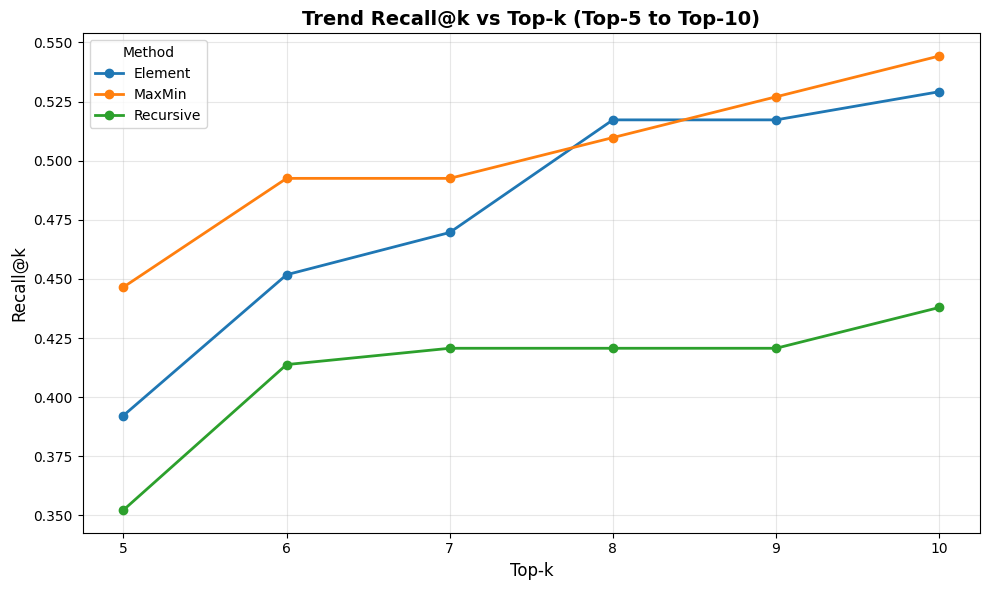

✓ Chart 1 saved to ..\results\final\figures\chart1_recall_trend.png


In [3]:
# Chart 1: Recall trend
plt.figure(figsize=(10, 6))
for method in trend['method_short'].unique():
    subset = trend[trend['method_short'] == method]
    plt.plot(subset['top_k'], subset['recall_at_k'], marker='o', label=method, linewidth=2)

plt.xlabel('Top-k', fontsize=12)
plt.ylabel('Recall@k', fontsize=12)
plt.title('Trend Recall@k vs Top-k (Top-5 to Top-10)', fontsize=14, fontweight='bold')
plt.legend(title='Method', fontsize=10)
plt.grid(alpha=0.3)
plt.xticks(range(TOPK_MIN, TOPK_MAX + 1))
plt.tight_layout()
plt.savefig(FIG_DIR / 'chart1_recall_trend.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"✓ Chart 1 saved to {FIG_DIR / 'chart1_recall_trend.png'}")

In [4]:
# Tabel 1: Recall trend
table1 = trend.pivot(index='top_k', columns='method_short', values='recall_at_k')
print("\n📊 Tabel 1: Recall@k per Metode dan Top-k")
display(table1.style.format("{:.4f}").highlight_max(color="#c8e6c9", axis=1))

# Export CSV
table1.to_csv(FIG_DIR / 'table1_recall_trend.csv')
print(f"✓ Table 1 exported to {FIG_DIR / 'table1_recall_trend.csv'}")


📊 Tabel 1: Recall@k per Metode dan Top-k


method_short,Element,MaxMin,Recursive
top_k,,,
5,0.3923,0.4466,0.3523
6,0.4518,0.4925,0.4138
7,0.4696,0.4925,0.4207
8,0.5173,0.5098,0.4207
9,0.5173,0.5270,0.4207
10,0.5292,0.5443,0.4379


✓ Table 1 exported to ..\results\final\figures\table1_recall_trend.csv


## Chart 2: Trend MRR vs Top-k

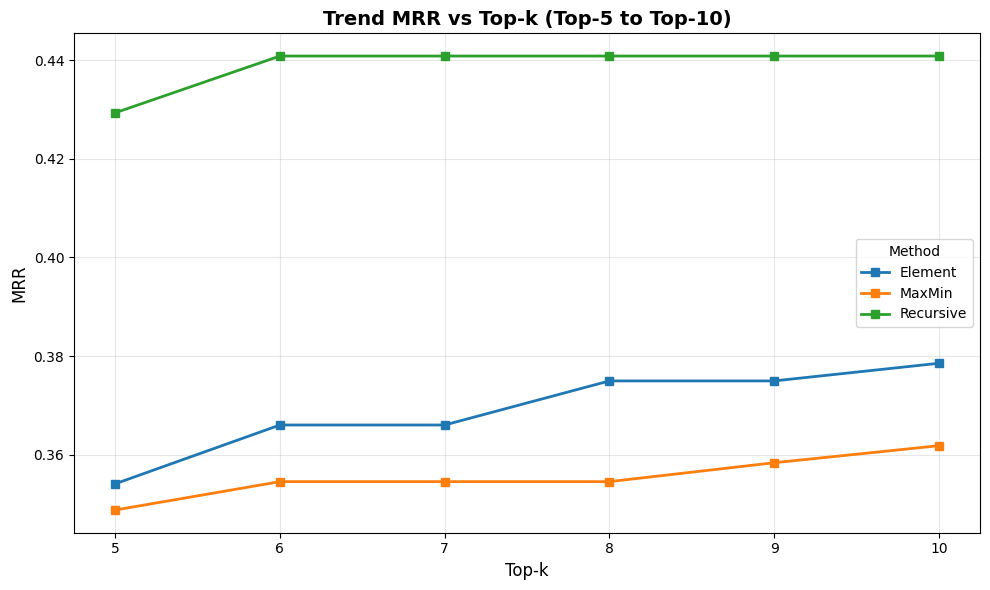

✓ Chart 2 saved to ..\results\final\figures\chart2_mrr_trend.png


In [5]:
# Chart 2: MRR trend
plt.figure(figsize=(10, 6))
for method in trend['method_short'].unique():
    subset = trend[trend['method_short'] == method]
    plt.plot(subset['top_k'], subset['mrr'], marker='s', label=method, linewidth=2)

plt.xlabel('Top-k', fontsize=12)
plt.ylabel('MRR', fontsize=12)
plt.title('Trend MRR vs Top-k (Top-5 to Top-10)', fontsize=14, fontweight='bold')
plt.legend(title='Method', fontsize=10)
plt.grid(alpha=0.3)
plt.xticks(range(TOPK_MIN, TOPK_MAX + 1))
plt.tight_layout()
plt.savefig(FIG_DIR / 'chart2_mrr_trend.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"✓ Chart 2 saved to {FIG_DIR / 'chart2_mrr_trend.png'}")

In [6]:
# Tabel 2: MRR trend
table2 = trend.pivot(index='top_k', columns='method_short', values='mrr')
print("\n📊 Tabel 2: MRR per Metode dan Top-k")
display(table2.style.format("{:.4f}").highlight_max(color="#c8e6c9", axis=1))

# Export CSV
table2.to_csv(FIG_DIR / 'table2_mrr_trend.csv')
print(f"✓ Table 2 exported to {FIG_DIR / 'table2_mrr_trend.csv'}")


📊 Tabel 2: MRR per Metode dan Top-k


method_short,Element,MaxMin,Recursive
top_k,,,
5,0.3542,0.3488,0.4293
6,0.3661,0.3546,0.4408
7,0.3661,0.3546,0.4408
8,0.3750,0.3546,0.4408
9,0.3750,0.3584,0.4408
10,0.3786,0.3619,0.4408


✓ Table 2 exported to ..\results\final\figures\table2_mrr_trend.csv


## Chart 3: BLEU & ROUGE-L per Metode (Top-5)

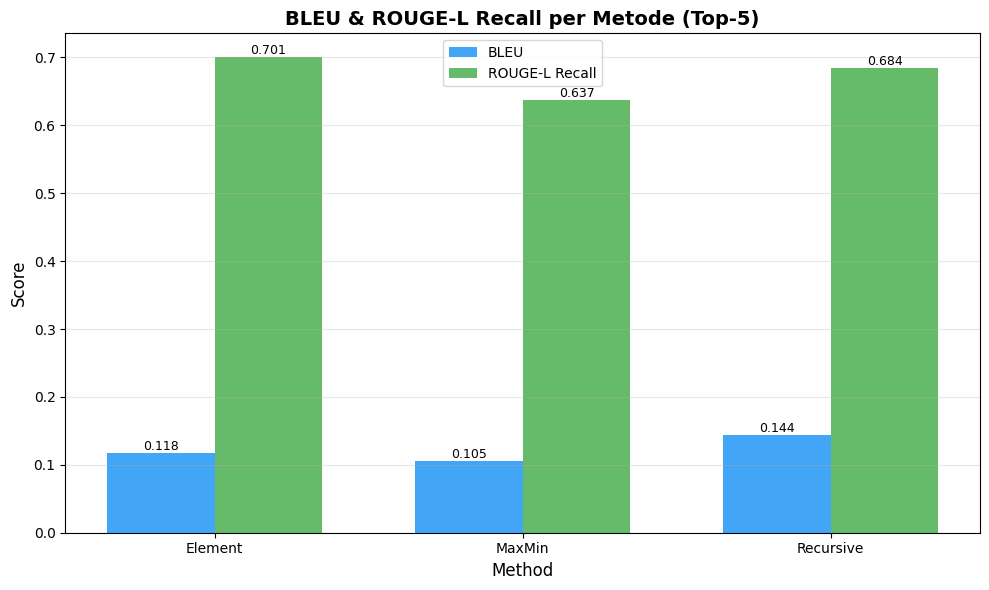

✓ Chart 3 saved to ..\results\final\figures\chart3_generation_metrics.png


In [7]:
# Chart 3: Generasi metrik (BLEU + ROUGE-L)
x = np.arange(len(gen_avg))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, gen_avg['bleu'], width, label='BLEU', color='#42a5f5')
bars2 = ax.bar(x + width/2, gen_avg['rouge_l_recall'], width, label='ROUGE-L Recall', color='#66bb6a')

ax.set_xlabel('Method', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title(f'BLEU & ROUGE-L Recall per Metode (Top-{TOPK_MIN})', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(gen_avg['method_short'])
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)

# Annotate values
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(FIG_DIR / 'chart3_generation_metrics.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"✓ Chart 3 saved to {FIG_DIR / 'chart3_generation_metrics.png'}")

In [8]:
# Tabel 3: Generasi metrik
table3 = gen_avg.set_index('method_short')[['bleu', 'rouge_l_recall']]
print(f"\n📊 Tabel 3: BLEU & ROUGE-L per Metode (Top-{TOPK_MIN})")
display(table3.style.format("{:.4f}").highlight_max(color="#c8e6c9", axis=0))

# Export CSV
table3.to_csv(FIG_DIR / 'table3_generation_metrics.csv')
print(f"✓ Table 3 exported to {FIG_DIR / 'table3_generation_metrics.csv'}")


📊 Tabel 3: BLEU & ROUGE-L per Metode (Top-5)


,bleu,rouge_l_recall
method_short,,
Element,0.1178,0.7005
MaxMin,0.1052,0.6369
Recursive,0.1440,0.6838


✓ Table 3 exported to ..\results\final\figures\table3_generation_metrics.csv


## Chart 4: Jumlah Query Berhasil (MRR > 0) per Top-k

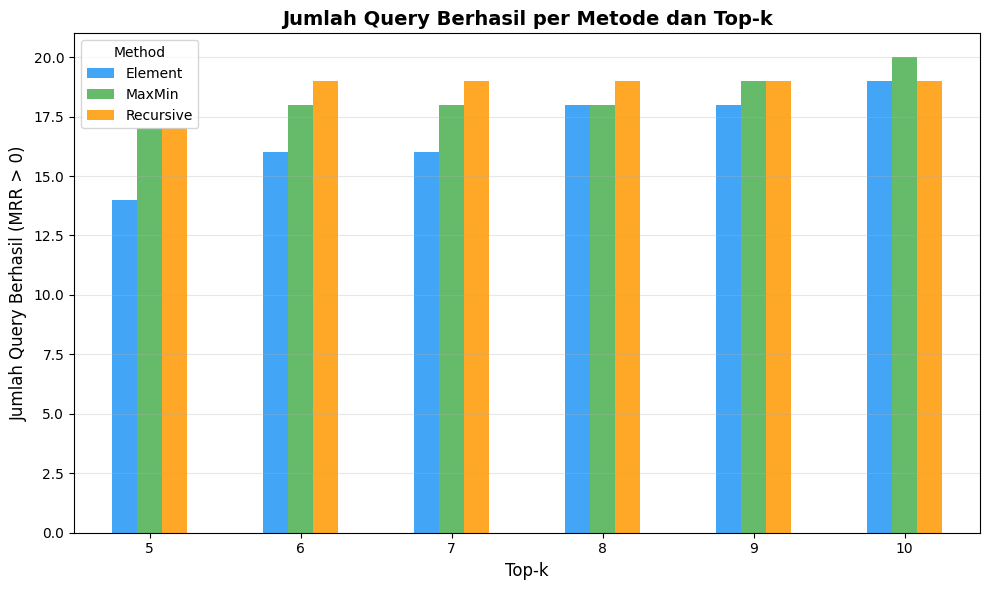

✓ Chart 4 saved to ..\results\final\figures\chart4_hit_count.png


In [9]:
# Chart 4: Hit count (grouped bar)
pivot_hit = hit_df.pivot(index='top_k', columns='method', values='hit_count')
pivot_hit.plot(kind='bar', figsize=(10, 6), color=['#42a5f5', '#66bb6a', '#ffa726'])

plt.xlabel('Top-k', fontsize=12)
plt.ylabel('Jumlah Query Berhasil (MRR > 0)', fontsize=12)
plt.title('Jumlah Query Berhasil per Metode dan Top-k', fontsize=14, fontweight='bold')
plt.legend(title='Method', fontsize=10)
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / 'chart4_hit_count.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"✓ Chart 4 saved to {FIG_DIR / 'chart4_hit_count.png'}")

In [10]:
# Tabel 4: Hit count
table4 = pivot_hit
print("\n📊 Tabel 4: Jumlah Query Berhasil (MRR > 0) per Top-k")
display(table4.style.highlight_max(color="#c8e6c9", axis=1))

# Export CSV
table4.to_csv(FIG_DIR / 'table4_hit_count.csv')
print(f"✓ Table 4 exported to {FIG_DIR / 'table4_hit_count.csv'}")


📊 Tabel 4: Jumlah Query Berhasil (MRR > 0) per Top-k


method,Element,MaxMin,Recursive
top_k,,,
5,14,17,17
6,16,18,19
7,16,18,19
8,18,18,19
9,18,19,19
10,19,20,19


✓ Table 4 exported to ..\results\final\figures\table4_hit_count.csv


## Chart 5: Heatmap MRR@5 per Query per Metode

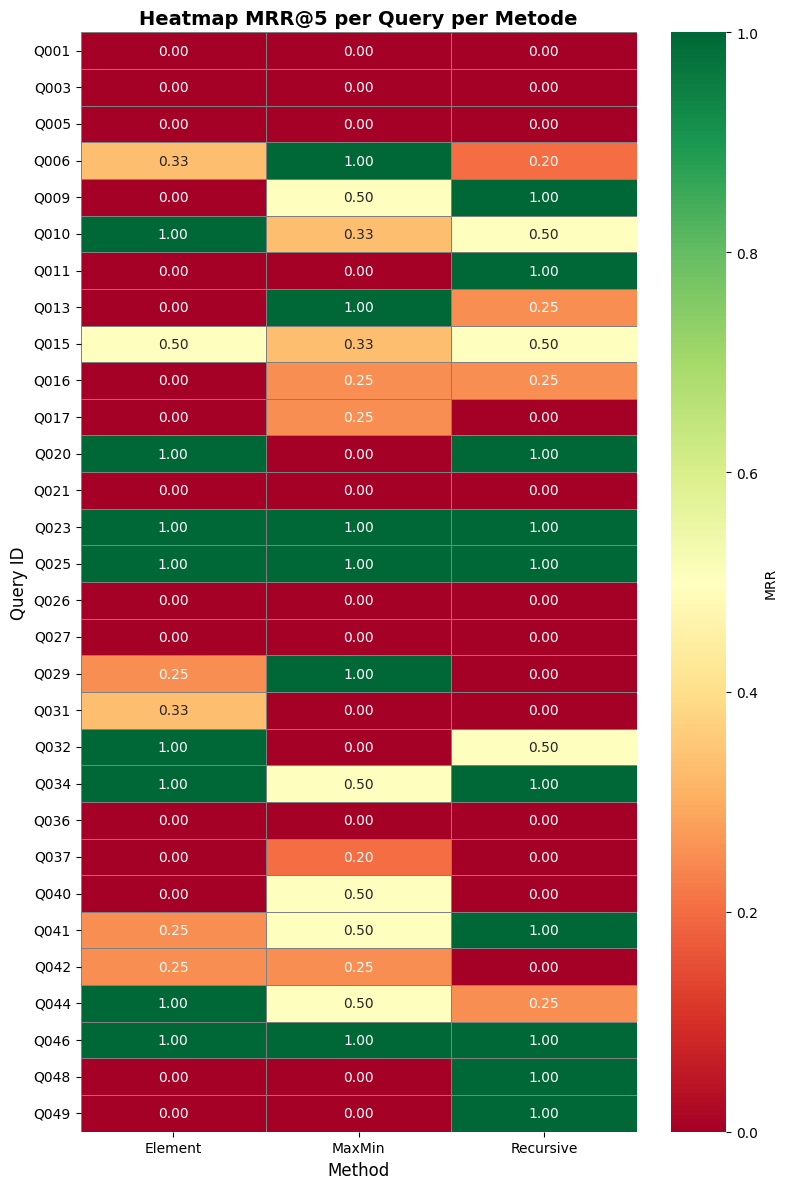

✓ Chart 5 saved to ..\results\final\figures\chart5_heatmap_mrr.png

(Heatmap sudah menampilkan semua nilai numerik — tabel terpisah tidak diperlukan)


In [11]:
# Chart 5: Heatmap MRR per query
plt.figure(figsize=(8, 12))
sns.heatmap(heatmap_data, annot=True, fmt=".2f", cmap="RdYlGn", cbar_kws={'label': 'MRR'},
            linewidths=0.5, linecolor='gray', vmin=0, vmax=1)
plt.xlabel('Method', fontsize=12)
plt.ylabel('Query ID', fontsize=12)
plt.title(f'Heatmap MRR@{TOPK_MIN} per Query per Metode', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'chart5_heatmap_mrr.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"✓ Chart 5 saved to {FIG_DIR / 'chart5_heatmap_mrr.png'}")
print("\n(Heatmap sudah menampilkan semua nilai numerik — tabel terpisah tidak diperlukan)")

## Chart 6: Radar Chart Semua Metrik (Top-5)

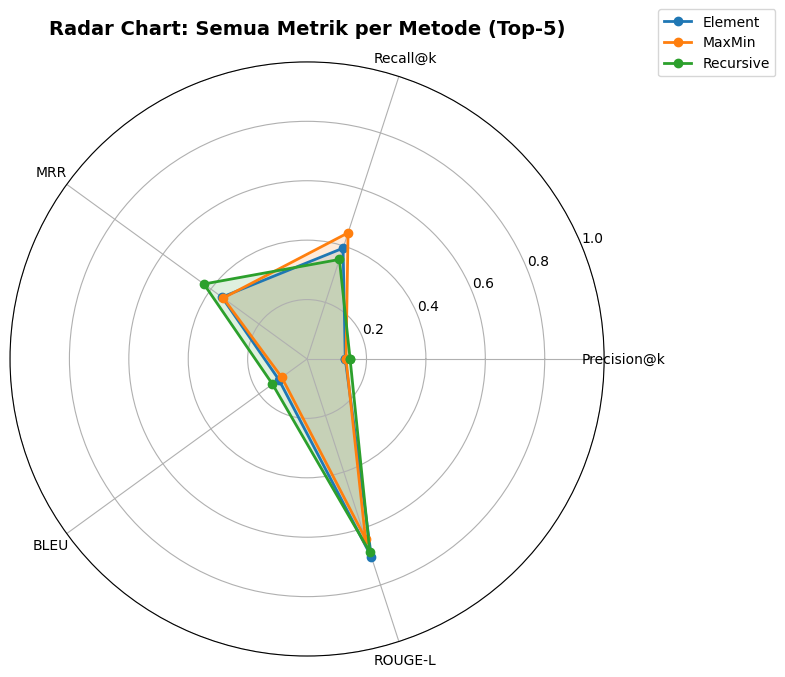

✓ Chart 6 saved to ..\results\final\figures\chart6_radar_all_metrics.png


In [12]:
# Chart 6: Radar chart
radar_metrics = ['precision_at_k', 'recall_at_k', 'mrr', 'bleu', 'rouge_l_recall']
radar_labels = ['Precision@k', 'Recall@k', 'MRR', 'BLEU', 'ROUGE-L']

radar_data = top5.groupby('method_short')[radar_metrics].mean()

# Radar plot
angles = np.linspace(0, 2 * np.pi, len(radar_metrics), endpoint=False).tolist()
angles += angles[:1]  # close the plot

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(projection='polar'))

for method in radar_data.index:
    values = radar_data.loc[method].tolist()
    values += values[:1]  # close the plot
    ax.plot(angles, values, 'o-', linewidth=2, label=method)
    ax.fill(angles, values, alpha=0.15)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_labels, fontsize=10)
ax.set_ylim(0, 1)
ax.set_title(f'Radar Chart: Semua Metrik per Metode (Top-{TOPK_MIN})', fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=10)
ax.grid(True)

plt.tight_layout()
plt.savefig(FIG_DIR / 'chart6_radar_all_metrics.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"✓ Chart 6 saved to {FIG_DIR / 'chart6_radar_all_metrics.png'}")

In [13]:
# Tabel 6: Summary radar (semua metrik)
table6 = radar_data
table6.columns = radar_labels
print(f"\n📊 Tabel 6: Summary Semua Metrik per Metode (Top-{TOPK_MIN})")
display(table6.style.format("{:.4f}").highlight_max(color="#c8e6c9", axis=0))

# Export CSV
table6.to_csv(FIG_DIR / 'table6_summary_all_metrics.csv')
print(f"✓ Table 6 exported to {FIG_DIR / 'table6_summary_all_metrics.csv'}")


📊 Tabel 6: Summary Semua Metrik per Metode (Top-5)


,Precision@k,Recall@k,MRR,BLEU,ROUGE-L
method_short,,,,,
Element,0.1286,0.3923,0.3542,0.1178,0.7005
MaxMin,0.1310,0.4466,0.3488,0.1052,0.6369
Recursive,0.1448,0.3523,0.4293,0.1440,0.6838


✓ Table 6 exported to ..\results\final\figures\table6_summary_all_metrics.csv


## Summary

Semua visualisasi dan tabel telah di-generate dan disimpan di `results/final/figures/`:
- **6 Chart PNG** (resolusi 300 DPI untuk laporan)
- **6 Tabel CSV** (untuk analisis numerik lanjutan)

Visualisasi mencakup top-5 hingga top-10 sesuai request user.